# Projet Deep Learning - Version 1

## 1.Importation des packages

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

torch.manual_seed(0)

device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print('Device utilisé :', device)

Device utilisé : mps


## 2.Importation et exploration des données

### 2.1 Chargement des données

In [2]:
#Chargement des données
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

### 2.2 Exploration des données

In [3]:
# Exploration des données
print("Aperçu des données d'entraînement :")
print(train.head())
print("\nInformations sur les données d'entraînement :")
print(train.info())
print("\nStatistiques descriptives des données d'entraînement :")
print(train.describe())
print("\nDistribution des classes cibles :")
print(train['Activity'].value_counts())

Aperçu des données d'entraînement :
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   
2         -0.967187         -0.978944         -0.996520         -0.963668   
3         -0.983403         -0.990675         -0.997099         -0.982750   
4         -0.980817         -0.990482         -0.998321         -0.979672   

   tBodyAcc-mad()-Z 

### 2.3 Visualisation des données

In [ ]:
# Avec l'aide de ChatGPT

## 3.Préparation des données

### 3.1 Configuration d'apprentissage

In [4]:
#Configuration d'apprentissage
CONFIG = {
    'BATCH_SIZE': 32,
    'EPOCHS': 100,
    'LR': 1e-3
}

### 3.2 Préparation des données

In [5]:
#Préparation des données
X_train = train.drop('Activity', axis=1).values
y_train = train['Activity'].values
X_test = test.drop('Activity', axis=1).values
y_test = test['Activity'].values

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#Create tensors
X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train = torch.tensor(y_train, dtype=torch.long, device=device)
X_test = torch.tensor(X_test, dtype=torch.float32, device=device)
y_test = torch.tensor(y_test, dtype=torch.long, device=device)

#Create dataset
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

#Create data loader with batchs
trainloader = DataLoader(train_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=True)
testloader  = DataLoader(test_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=True)

## 4.Modèle et fonction d'entraînement

### 4.1 Modèle

In [6]:
class ActivityClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, activation):
        super(ActivityClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.activation = activation

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.fc2(x)
        return x

### 4.2 Fonction train_epoch

In [7]:
def train_epoch(model, loader, optimizer, lossfn, device):
    model.train()
    training_loss = 0.0
    training_acc = 0
    total = 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = lossfn(logits, y)
        loss.backward()
        optimizer.step()
        training_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        training_acc += (preds==y).sum().item()
        total += x.size(0)
    return training_loss/total, training_acc/total

### 4.3 Fonction evaluate

In [8]:
def evaluate(model, loader, lossfn, device):
    model.eval()
    test_loss = 0.0
    test_acc = 0
    total = 0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            logits = model(x)
            loss = lossfn(logits, y)
            test_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            test_acc += (preds==y).sum().item()
            total += x.size(0)
    return test_loss/total, test_acc/total

### 4.4 Fonction compute_train_history

In [9]:
def compute_train_history(mlp, trainloader, testloader, optimizer, lossfn, device, epochs):
    history_mlp = {"epoch": [], 'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[]}
    for epoch in range(1, epochs + 1):
        history_mlp["epoch"].append(epoch)
        # TODO : Compléter la boucle d'entraînement et d'évaluation du modèle MLP
        train_loss, train_acc = train_epoch(mlp, trainloader, optimizer, lossfn, device)
    
        history_mlp["train_loss"].append(train_loss)
        history_mlp["train_acc"].append(train_acc)

        test_loss, test_acc = evaluate(mlp, testloader, lossfn, device)

        history_mlp["test_loss"].append(test_loss)
        history_mlp["test_acc"].append(test_acc)
        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    return history_mlp

### 4.5 Fonction plot_train_history

In [10]:
def plot_training_history(history_mlp, title_suffix=''):
    # --- FIGURE 1 : Train Accuracy ---
    figure, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
    axes[0].plot(history_mlp['train_acc'], label='MLP')
    axes[0].set_title(" Train Accuracy -" + title_suffix)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # --- FIGURE 2 : Test Accuracy ---
    axes[1].plot(history_mlp['test_acc'], label='MLP')
    axes[1].set_title('Test Accuracy -' + title_suffix)
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)
    plt.show()

## 5.Boucle d'entraînement

### 5.1 Apprentissage avec RELU

1. Activation: RELU
2. Optimizer: Adam
3. Critère: nn.CrossEntropyLoss()

==> Entraînement du modèle MLP avec ReLU (Modèle 5.1)
Epoch 10/100 - Train Loss: 0.0264, Train Acc: 0.9902, Test Loss: 0.2485, Test Acc: 0.9352
Epoch 20/100 - Train Loss: 0.0049, Train Acc: 0.9988, Test Loss: 0.2912, Test Acc: 0.9379
Epoch 30/100 - Train Loss: 0.0004, Train Acc: 1.0000, Test Loss: 0.3361, Test Acc: 0.9403
Epoch 40/100 - Train Loss: 0.0002, Train Acc: 1.0000, Test Loss: 0.3590, Test Acc: 0.9406
Epoch 50/100 - Train Loss: 0.0001, Train Acc: 1.0000, Test Loss: 0.3921, Test Acc: 0.9403
Epoch 60/100 - Train Loss: 0.0001, Train Acc: 1.0000, Test Loss: 0.4806, Test Acc: 0.9362
Epoch 70/100 - Train Loss: 0.0000, Train Acc: 1.0000, Test Loss: 0.5008, Test Acc: 0.9372
Epoch 80/100 - Train Loss: 0.0000, Train Acc: 1.0000, Test Loss: 0.5036, Test Acc: 0.9389
Epoch 90/100 - Train Loss: 0.0001, Train Acc: 1.0000, Test Loss: 0.4258, Test Acc: 0.9454
Epoch 100/100 - Train Loss: 0.0000, Train Acc: 1.0000, Test Loss: 0.4605, Test Acc: 0.9437


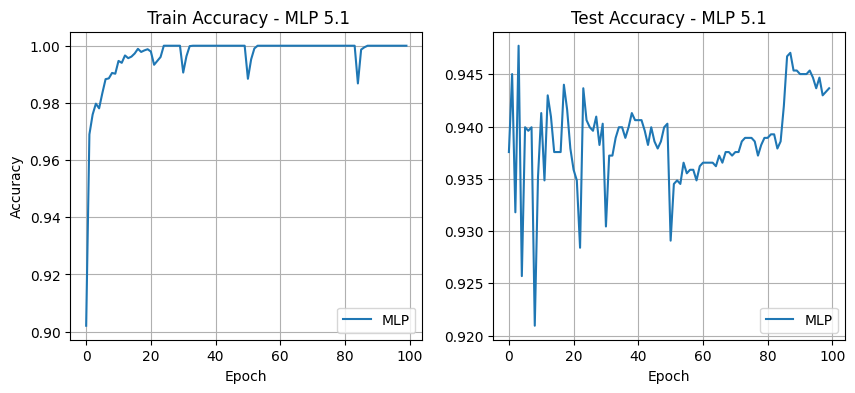

In [11]:
# --- Modèle 5.1 --
mlp_5_1= ActivityClassifier(input_dim=X_train.shape[1], num_classes=len(le.classes_), activation=F.relu)
mlp_5_1 = mlp_5_1.to(device)
optimizer = torch.optim.Adam(mlp_5_1.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec ReLU (Modèle 5.1)")
history_mlp_5_1 = compute_train_history(mlp_5_1, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_5_1, title_suffix=' MLP 5.1')

### 5.2 Apprentissage avec Sigmoïd

1. Activation: Sigmoïd
2. Optimizer: Adam
3. Critère: nn.CrossEntropyLoss()

==> Entraînement du modèle MLP avec Sigmoid (Modèle 5.2)
Epoch 10/100 - Train Loss: 0.0314, Train Acc: 0.9886, Test Loss: 0.1587, Test Acc: 0.9464
Epoch 20/100 - Train Loss: 0.0104, Train Acc: 0.9969, Test Loss: 0.1815, Test Acc: 0.9494
Epoch 30/100 - Train Loss: 0.0017, Train Acc: 1.0000, Test Loss: 0.2423, Test Acc: 0.9447
Epoch 40/100 - Train Loss: 0.0006, Train Acc: 1.0000, Test Loss: 0.2675, Test Acc: 0.9454
Epoch 50/100 - Train Loss: 0.0002, Train Acc: 1.0000, Test Loss: 0.2877, Test Acc: 0.9474
Epoch 60/100 - Train Loss: 0.0001, Train Acc: 1.0000, Test Loss: 0.2910, Test Acc: 0.9484
Epoch 70/100 - Train Loss: 0.0003, Train Acc: 1.0000, Test Loss: 0.2643, Test Acc: 0.9447
Epoch 80/100 - Train Loss: 0.0001, Train Acc: 1.0000, Test Loss: 0.2646, Test Acc: 0.9454
Epoch 90/100 - Train Loss: 0.0000, Train Acc: 1.0000, Test Loss: 0.2912, Test Acc: 0.9430
Epoch 100/100 - Train Loss: 0.0000, Train Acc: 1.0000, Test Loss: 0.3137, Test Acc: 0.9457


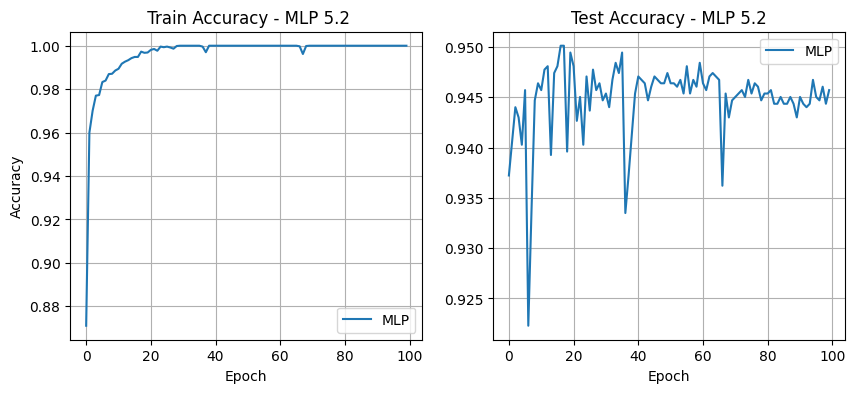

In [12]:
# --- Modèle 5.2 --
mlp_5_2= ActivityClassifier(input_dim=X_train.shape[1], num_classes=len(le.classes_), activation=F.sigmoid)
mlp_5_2 = mlp_5_2.to(device)
optimizer = torch.optim.Adam(mlp_5_2.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec Sigmoid (Modèle 5.2)")
history_mlp_5_2 = compute_train_history(mlp_5_2, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_5_2, title_suffix=' MLP 5.2')

### 5.3 Apprentissage avec Tanh

1. Activation: Tanh
2. Optimizer: Adam
3. Critère: nn.CrossEntropyLoss()

==> Entraînement du modèle MLP avec Tanh (Modèle 5.3)
Epoch 10/100 - Train Loss: 0.0188, Train Acc: 0.9950, Test Loss: 0.1954, Test Acc: 0.9413
Epoch 20/100 - Train Loss: 0.0026, Train Acc: 0.9996, Test Loss: 0.2277, Test Acc: 0.9457
Epoch 30/100 - Train Loss: 0.0008, Train Acc: 1.0000, Test Loss: 0.2656, Test Acc: 0.9444
Epoch 40/100 - Train Loss: 0.0002, Train Acc: 1.0000, Test Loss: 0.2565, Test Acc: 0.9498
Epoch 50/100 - Train Loss: 0.0001, Train Acc: 1.0000, Test Loss: 0.2687, Test Acc: 0.9505
Epoch 60/100 - Train Loss: 0.0163, Train Acc: 0.9950, Test Loss: 0.2019, Test Acc: 0.9464
Epoch 70/100 - Train Loss: 0.0004, Train Acc: 1.0000, Test Loss: 0.2131, Test Acc: 0.9542
Epoch 80/100 - Train Loss: 0.0001, Train Acc: 1.0000, Test Loss: 0.2264, Test Acc: 0.9559
Epoch 90/100 - Train Loss: 0.0000, Train Acc: 1.0000, Test Loss: 0.2434, Test Acc: 0.9579
Epoch 100/100 - Train Loss: 0.0000, Train Acc: 1.0000, Test Loss: 0.2684, Test Acc: 0.9562


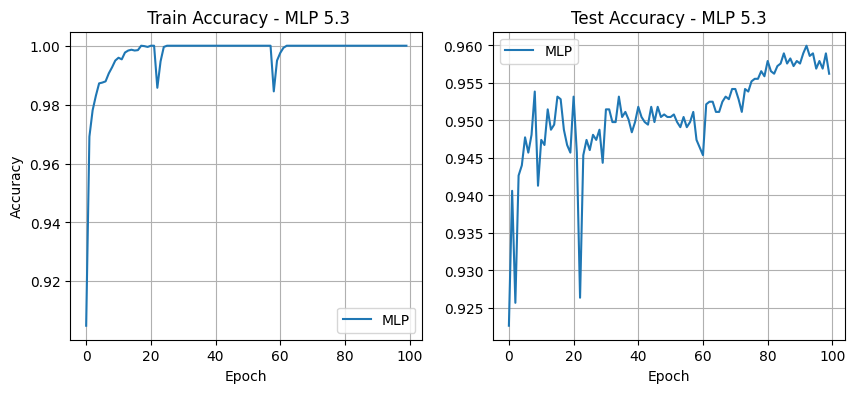

In [13]:
# --- Modèle 5.3 --
mlp_5_3= ActivityClassifier(input_dim=X_train.shape[1], num_classes=len(le.classes_), activation=F.tanh)
mlp_5_3 = mlp_5_3.to(device)
optimizer = torch.optim.Adam(mlp_5_3.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec Tanh (Modèle 5.3)")
history_mlp_5_3 = compute_train_history(mlp_5_3, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_5_3, title_suffix=' MLP 5.3')

### 5.4 Apprentissage avec SGD

1. Activation: RELU
2. Optimizer: SGD
3. Critère: nn.CrossEntropyLoss()

==> Entraînement du modèle MLP avec SGD (Modèle 5.4)
Epoch 10/100 - Train Loss: 0.3976, Train Acc: 0.8924, Test Loss: 0.4169, Test Acc: 0.8843
Epoch 20/100 - Train Loss: 0.2337, Train Acc: 0.9359, Test Loss: 0.2724, Test Acc: 0.9189
Epoch 30/100 - Train Loss: 0.1690, Train Acc: 0.9518, Test Loss: 0.2184, Test Acc: 0.9270
Epoch 40/100 - Train Loss: 0.1347, Train Acc: 0.9627, Test Loss: 0.1902, Test Acc: 0.9369
Epoch 50/100 - Train Loss: 0.1138, Train Acc: 0.9689, Test Loss: 0.1770, Test Acc: 0.9379
Epoch 60/100 - Train Loss: 0.0995, Train Acc: 0.9727, Test Loss: 0.1662, Test Acc: 0.9403
Epoch 70/100 - Train Loss: 0.0891, Train Acc: 0.9754, Test Loss: 0.1616, Test Acc: 0.9406
Epoch 80/100 - Train Loss: 0.0813, Train Acc: 0.9773, Test Loss: 0.1590, Test Acc: 0.9410
Epoch 90/100 - Train Loss: 0.0750, Train Acc: 0.9789, Test Loss: 0.1591, Test Acc: 0.9396
Epoch 100/100 - Train Loss: 0.0701, Train Acc: 0.9807, Test Loss: 0.1552, Test Acc: 0.9413


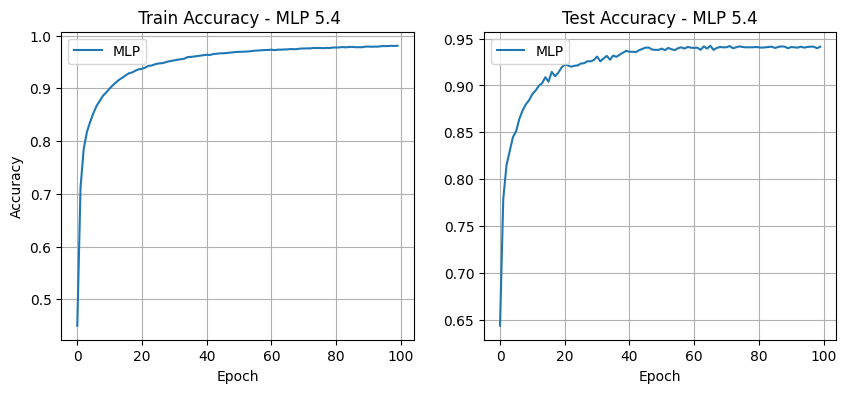

In [14]:
# --- Modèle 5.4 --
mlp_5_4= ActivityClassifier(input_dim=X_train.shape[1], num_classes=len(le.classes_), activation=F.relu)
mlp_5_4 = mlp_5_4.to(device)
optimizer = torch.optim.SGD(mlp_5_4.parameters(), lr=CONFIG['LR'])
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec SGD (Modèle 5.4)")
history_mlp_5_4 = compute_train_history(mlp_5_4, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_5_4, title_suffix=' MLP 5.4')

### 5.5 Apprentissage avec SGD Momentum

1. Activation: RELU
2. Optimizer: SGD Momentum
3. Critère: nn.CrossEntropyLoss()

==> Entraînement du modèle MLP avec SGD avec Momentum (Modèle 5.5)
Epoch 10/100 - Train Loss: 0.0752, Train Acc: 0.9778, Test Loss: 0.1478, Test Acc: 0.9457
Epoch 20/100 - Train Loss: 0.0479, Train Acc: 0.9852, Test Loss: 0.1511, Test Acc: 0.9427
Epoch 30/100 - Train Loss: 0.0394, Train Acc: 0.9878, Test Loss: 0.1572, Test Acc: 0.9450
Epoch 40/100 - Train Loss: 0.0332, Train Acc: 0.9901, Test Loss: 0.1717, Test Acc: 0.9440
Epoch 50/100 - Train Loss: 0.0283, Train Acc: 0.9921, Test Loss: 0.1789, Test Acc: 0.9420
Epoch 60/100 - Train Loss: 0.0251, Train Acc: 0.9935, Test Loss: 0.1812, Test Acc: 0.9420
Epoch 70/100 - Train Loss: 0.0225, Train Acc: 0.9924, Test Loss: 0.1758, Test Acc: 0.9467
Epoch 80/100 - Train Loss: 0.0193, Train Acc: 0.9937, Test Loss: 0.2054, Test Acc: 0.9386
Epoch 90/100 - Train Loss: 0.0175, Train Acc: 0.9948, Test Loss: 0.2105, Test Acc: 0.9386
Epoch 100/100 - Train Loss: 0.0155, Train Acc: 0.9952, Test Loss: 0.1828, Test Acc: 0.9471


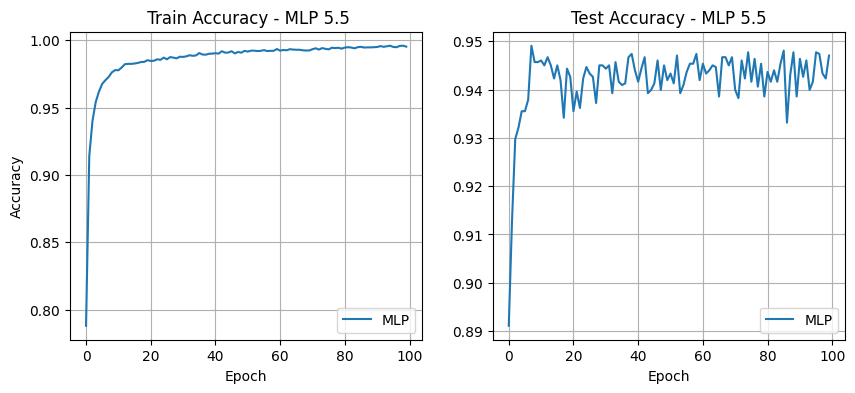

In [15]:
# --- Modèle 5.5 --
mlp_5_5= ActivityClassifier(input_dim=X_train.shape[1], num_classes=len(le.classes_), activation=F.relu)
mlp_5_5 = mlp_5_5.to(device)
optimizer = torch.optim.SGD(mlp_5_5.parameters(), lr=CONFIG['LR'], momentum=0.9)
lossfn = nn.CrossEntropyLoss()

print("==> Entraînement du modèle MLP avec SGD avec Momentum (Modèle 5.5)")
history_mlp_5_5 = compute_train_history(mlp_5_5, trainloader, testloader, optimizer, lossfn, device, CONFIG['EPOCHS'])
plot_training_history(history_mlp_5_5, title_suffix=' MLP 5.5')